# 05 - Dataset Loader

**Purpose:** Build and validate the dataset table used by ML.

**Expected output:** Clean dataframe with image path, split, label, target, dimensions, and mask path.

**Platform connection:** Model code needs a stable dataset contract before evaluation or inference.


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())

from ml.dataset_loader import load_bottle_dataframe


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Load Dataset Table


In [2]:
dataset_df = load_bottle_dataframe()
print("Total records:", len(dataset_df))
display(dataset_df.head(10))


Total records: 292


,split,label,target,target_name,is_defective,image_path,mask_path,width,height,channels
0,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
1,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
2,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
3,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
4,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
5,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
6,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
7,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
8,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
9,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3


## Output Contract And Validation


In [3]:
required_columns = ["split", "label", "target", "target_name", "is_defective", "image_path", "mask_path", "width", "height", "channels"]
display(pd.DataFrame([{"column": col, "present": col in dataset_df.columns} for col in required_columns]))
display(pd.DataFrame([
    {"check": "dataset not empty", "passed": not dataset_df.empty},
    {"check": "all image paths exist", "passed": dataset_df["image_path"].map(lambda p: Path(p).exists()).all()},
    {"check": "expected labels present", "passed": set(LABELS).issubset(set(dataset_df["label"].unique()))},
]))


,column,present
0,split,True
1,label,True
2,target,True
3,target_name,True
4,is_defective,True
5,image_path,True
6,mask_path,True
7,width,True
8,height,True
9,channels,True


,check,passed
0,dataset not empty,True
1,all image paths exist,True
2,expected labels present,True


## Summary, Sizes, And Mask Validity


In [4]:
display(dataset_df.groupby(["split", "label", "target_name"]).size().reset_index(name="count"))
display(dataset_df.groupby(["width", "height", "channels"]).size().reset_index(name="count").sort_values("count", ascending=False).head(10))
mask_check = dataset_df[dataset_df["split"].eq("test")].copy()
mask_check["mask_valid"] = mask_check.apply(lambda row: True if row["label"] == "good" else isinstance(row["mask_path"], str) and Path(row["mask_path"]).exists(), axis=1)
display(mask_check.groupby(["label", "mask_valid"]).size().reset_index(name="count"))


,split,label,target_name,count
0,test,broken_large,defective,20
1,test,broken_small,defective,22
2,test,contamination,defective,21
3,test,good,good,20
4,train,good,good,209


,width,height,channels,count
0,900,900,3,292


,label,mask_valid,count
0,broken_large,True,20
1,broken_small,True,22
2,contamination,True,21
3,good,True,20


## Loader Sample Grid


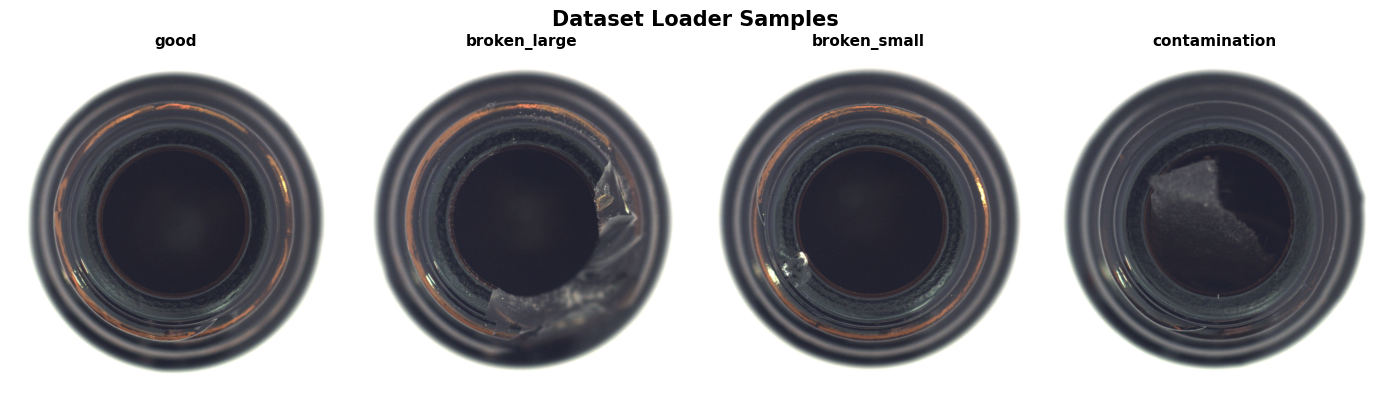

In [5]:
items = []
for label in LABELS:
    row = dataset_df[(dataset_df["split"].eq("test")) & (dataset_df["label"].eq(label))].iloc[0]
    items.append((label, read_rgb(row["image_path"]), None))
show_grid(items, cols=4, figsize=(14, 4), suptitle="Dataset Loader Samples")


## Data Loader QA Report

This verifies that the loader output is ready for both model code and backend analytics.


In [6]:
qa_rows = [
    {"check": "unique image paths", "value": dataset_df["image_path"].nunique(), "expected": len(dataset_df), "passed": dataset_df["image_path"].nunique() == len(dataset_df)},
    {"check": "no null labels", "value": int(dataset_df["label"].isna().sum()), "expected": 0, "passed": dataset_df["label"].notna().all()},
    {"check": "binary targets only", "value": sorted(dataset_df["target"].dropna().unique().tolist()), "expected": [0, 1], "passed": set(dataset_df["target"].unique()).issubset({0, 1})},
    {"check": "train split normal only", "value": sorted(dataset_df[dataset_df["split"].eq("train")]["label"].unique().tolist()), "expected": ["good"], "passed": sorted(dataset_df[dataset_df["split"].eq("train")]["label"].unique().tolist()) == ["good"]},
]
display(pd.DataFrame(qa_rows))

analytics_ready_df = dataset_df.assign(has_mask=dataset_df["mask_path"].notna()).groupby(["split", "target_name", "has_mask"]).size().reset_index(name="records")
display(analytics_ready_df)


,check,value,expected,passed
0,unique image paths,292,292,True
1,no null labels,0,0,True
2,binary targets only,"[0, 1]","[0, 1]",True
3,train split normal only,[good],[good],True


,split,target_name,has_mask,records
0,test,defective,True,63
1,test,good,False,20
2,train,good,False,209


## Validation Outcome

- The loader returns the metadata required by model, backend, and analytics layers.
- Image paths, labels, masks, and dimensions are validated before model work begins.
- No external dataset report file is needed; the notebook shows the contract inline.
